# CEREBRO PoC — 06 Integrated Knowledge Experience

**Experiment:** EXP-INTEGRATION-001  
**Stage:** Knowledge Experience Integration  
**Inputs:** Registered Artifact + Knowledge Model + Semantic Candidates  
**Outputs:** Integrated Galaxy + Timeline + Assisted Recollection View

---

## Objective

Validate that the persisted outputs produced by the CEREBRO pipeline can be assembled into a single coherent Digital Knowledge Twin experience.

This experiment does not generate new knowledge.

It integrates previously validated outputs:

**Registered Artifact → Knowledge Model → Semantic Candidates → Galaxy / Timeline → Assisted Recollection → Source Evidence**

### Core Principle

**One Knowledge Model → Multiple Connected Experiences**

Galaxy, Timeline, and Assisted Recollection must operate on the same knowledge fragment identities.

No visualization should maintain an independent copy of trusted knowledge.

### 1 — Load Everything

In [1]:
from pathlib import Path
import json

repo_root = Path.cwd().parents[1]

artifact_path = (
    repo_root
    / "poc/data/processed/artifacts/ART-0001.json"
)

knowledge_path = (
    repo_root
    / "poc/data/processed/knowledge/KM-0001.json"
)

candidate_path = (
    repo_root
    / "poc/data/processed/knowledge/KM-0001-semantic-candidates.json"
)

assert artifact_path.exists(), artifact_path
assert knowledge_path.exists(), knowledge_path
assert candidate_path.exists(), candidate_path

with open(artifact_path, "r", encoding="utf-8") as f:
    registered_artifact = json.load(f)

with open(knowledge_path, "r", encoding="utf-8") as f:
    knowledge_model = json.load(f)

with open(candidate_path, "r", encoding="utf-8") as f:
    semantic_candidates = json.load(f)

fragments = knowledge_model["fragments"]
trusted_relationships = knowledge_model["relationships"]
candidate_relationships = semantic_candidates["candidate_relationships"]

print("✓ Persisted CEREBRO state loaded")
print("Artifact              :", registered_artifact["artifact_id"])
print("Knowledge model       :", knowledge_model["model_id"])
print("Fragments             :", len(fragments))
print("Trusted relationships :", len(trusted_relationships))
print("Candidate relationships:", len(candidate_relationships))

✓ Persisted CEREBRO state loaded
Artifact              : ART-0001
Knowledge model       : KM-0001
Fragments             : 3
Trusted relationships : 3
Candidate relationships: 3


## 2. Validate Integrated Knowledge Identity

Before visualization, CEREBRO verifies that all integrated components reference valid knowledge fragments.

The `KF-*` identifier is the common identity connecting:

- Galaxy
- Timeline
- Semantic relationships
- Assisted Recollection
- Source provenance

This prevents different application views from drifting into separate interpretations of the Digital Knowledge Twin.

### 2 — Validate IDs

In [2]:
fragment_ids = {
    fragment["fragment_id"]
    for fragment in fragments
}

for relationship in trusted_relationships:

    assert relationship["source"] in fragment_ids
    assert relationship["target"] in fragment_ids

for relationship in candidate_relationships:

    assert relationship["source"] in fragment_ids
    assert relationship["target"] in fragment_ids

assert knowledge_model["artifact_id"] == registered_artifact["artifact_id"]

print("✓ Fragment identities validated")
print("✓ Trusted relationships resolve")
print("✓ Candidate relationships resolve")
print("✓ Knowledge model resolves to registered artifact")

✓ Fragment identities validated
✓ Trusted relationships resolve
✓ Candidate relationships resolve
✓ Knowledge model resolves to registered artifact


## 3. Build the Integrated Knowledge Galaxy

The integrated Galaxy contains two relationship classes.

### Trusted Relationships

Relationships already accepted into the persisted knowledge model.

### Candidate Relationships

Machine-discovered semantic connections generated through embedding similarity.

Candidate relationships remain explicitly marked as candidates.

The visualization therefore exposes machine reasoning without confusing inference with established knowledge.

### 3 - Construct Graphh

In [3]:
import networkx as nx

G = nx.Graph()

for fragment in fragments:

    concepts = fragment["semantic"]["concepts"]

    label = (
        concepts[0]
        if concepts
        else fragment["fragment_id"]
    )

    G.add_node(
        fragment["fragment_id"],
        label=label,
        artifact_id=fragment["artifact_id"]
    )

for relationship in trusted_relationships:

    G.add_edge(
        relationship["source"],
        relationship["target"],
        relationship_type=relationship["type"],
        status="trusted"
    )

print("✓ Trusted Galaxy constructed")
print("Nodes:", G.number_of_nodes())
print("Trusted edges:", G.number_of_edges())

✓ Trusted Galaxy constructed
Nodes: 3
Trusted edges: 3


## 4. Render Trusted Knowledge and Candidate Evidence

For the PoC, trusted relationships form the primary Galaxy structure.

Machine-discovered semantic relationships are displayed as an explainability layer.

This reflects the CEREBRO principle:

**AI may propose connections. It does not silently redefine trusted knowledge.**

Future interactive visualization can provide controls to show or hide candidate relationships.

### 4 - Render Galaxy

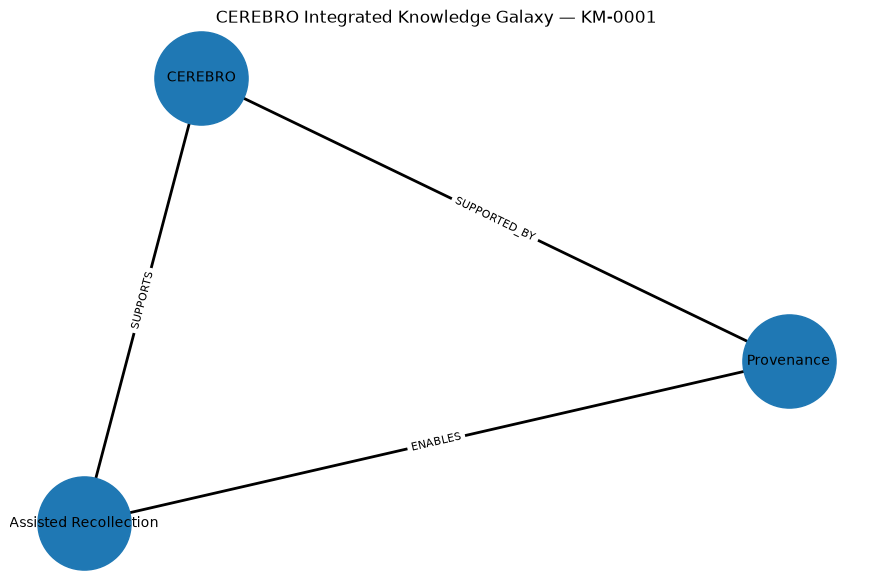

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

pos = nx.spring_layout(
    G,
    seed=42
)

labels = {
    node: G.nodes[node]["label"]
    for node in G.nodes
}

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=4500
)

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

trusted_edge_labels = {
    (u, v): data["relationship_type"]
    for u, v, data in G.edges(data=True)
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=trusted_edge_labels,
    font_size=8
)

plt.title(
    "CEREBRO Integrated Knowledge Galaxy — KM-0001"
)

plt.axis("off")
plt.show()

## 5. Inspect Machine-Discovered Connections

Candidate relationships provide additional semantic evidence for the Galaxy.

Each candidate retains:

- source fragment,
- target fragment,
- similarity evidence,
- relevance classification,
- embedding model,
- discovery method,
- candidate status.

This allows CEREBRO to explain why a connection was suggested.

### 5 - Show candidate evidence

In [5]:
for relationship in candidate_relationships:

    print(
        relationship["source"],
        "↔",
        relationship["target"]
    )

    print(
        "  Relevance :",
        relationship["relevance"]
    )

    print(
        "  Similarity:",
        relationship["similarity"]
    )

    print(
        "  Status    :",
        relationship["status"]
    )

    print(
        "  Model     :",
        relationship["model"]
    )

    print()

KF-0001 ↔ KF-0003
  Relevance : Related
  Similarity: 0.7228
  Status    : candidate
  Model     : mxbai-embed-large:latest

KF-0002 ↔ KF-0003
  Relevance : Related
  Similarity: 0.6948
  Status    : candidate
  Model     : mxbai-embed-large:latest

KF-0001 ↔ KF-0002
  Relevance : Related
  Similarity: 0.6841
  Status    : candidate
  Model     : mxbai-embed-large:latest



## 6. Build the Integrated Knowledge Timeline

The Timeline is another projection of the same `KF-*` knowledge fragments used by the Galaxy.

The Timeline does not create separate knowledge objects.

For the current benchmark, reliable historical knowledge dates are unavailable.

CEREBRO therefore uses verified ingestion time and preserves historical knowledge time as unknown.

### Principle

**Unknown time remains unknown.**

### 6 - Prepare timeline

In [6]:
from datetime import datetime

timeline_events = []

for fragment in fragments:

    temporal = fragment["temporal"]

    if temporal["ingested_at"]:

        timestamp = datetime.fromisoformat(
            temporal["ingested_at"]
        )

        concepts = fragment["semantic"]["concepts"]

        label = (
            concepts[0]
            if concepts
            else fragment["fragment_id"]
        )

        timeline_events.append({
            "fragment_id": fragment["fragment_id"],
            "timestamp": timestamp,
            "label": label,
            "event_type": "ingested"
        })

timeline_events = sorted(
    timeline_events,
    key=lambda event: event["timestamp"]
)

print(
    f"✓ {len(timeline_events)} "
    "timeline events prepared"
)

✓ 3 timeline events prepared


### 7 — Render Timeline

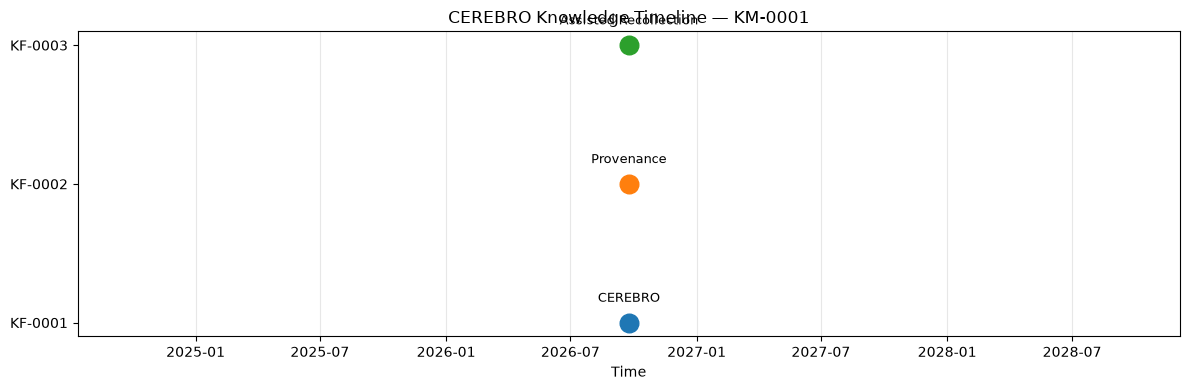

In [7]:
plt.figure(figsize=(12, 4))

for index, event in enumerate(timeline_events):

    plt.scatter(
        event["timestamp"],
        index,
        s=180
    )

    plt.text(
        event["timestamp"],
        index + 0.15,
        event["label"],
        ha="center",
        fontsize=9
    )

plt.yticks(
    range(len(timeline_events)),
    [
        event["fragment_id"]
        for event in timeline_events
    ]
)

plt.xlabel("Time")

plt.title(
    "CEREBRO Knowledge Timeline — KM-0001"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 7. Integrated Assisted Recollection

Galaxy and Timeline navigation ultimately resolve to the same knowledge fragment.

Selecting a fragment should allow CEREBRO to reconstruct:

- the knowledge statement,
- semantic concepts,
- trusted relationships,
- machine-discovered candidate relationships,
- source artifact,
- exact source location,
- supporting evidence.

The evidence path remains deterministic.

An LLM is not required to establish where trusted knowledge originated.

### 8 — Integrated Recollection Function

In [8]:
def recollect(fragment_id):

    fragment = next(
        fragment
        for fragment in fragments
        if fragment["fragment_id"] == fragment_id
    )

    location = fragment["source_location"]

    source_uri = registered_artifact["source"]["storage_uri"]

    source_path = repo_root / source_uri

    assert source_path.exists()

    source_text = source_path.read_text(
        encoding="utf-8"
    )

    evidence = source_text[
        location["start"]:
        location["end"]
    ]

    trusted_related = []

    for relationship in trusted_relationships:

        if relationship["source"] == fragment_id:

            trusted_related.append({
                "fragment_id":
                    relationship["target"],

                "relationship":
                    relationship["type"]
            })

        elif relationship["target"] == fragment_id:

            trusted_related.append({
                "fragment_id":
                    relationship["source"],

                "relationship":
                    relationship["type"]
            })

    candidate_related = []

    for relationship in candidate_relationships:

        if relationship["source"] == fragment_id:

            candidate_related.append({
                "fragment_id":
                    relationship["target"],

                "relevance":
                    relationship["relevance"],

                "similarity":
                    relationship["similarity"]
            })

        elif relationship["target"] == fragment_id:

            candidate_related.append({
                "fragment_id":
                    relationship["source"],

                "relevance":
                    relationship["relevance"],

                "similarity":
                    relationship["similarity"]
            })

    return {
        "fragment_id":
            fragment_id,

        "knowledge":
            fragment["content"],

        "concepts":
            fragment["semantic"]["concepts"],

        "trusted_relationships":
            trusted_related,

        "candidate_relationships":
            candidate_related,

        "source_artifact":
            fragment["artifact_id"],

        "source_file":
            fragment["provenance"]["source_filename"],

        "source_location":
            location,

        "evidence":
            evidence
    }

## 8. Demonstrate Connected Navigation

The same knowledge fragment can now act as the navigation anchor across the CEREBRO experience.

Example:

**Galaxy Node**

`KF-0002`

↓

**Knowledge Fragment**

`Provenance`

↓

**Trusted + Candidate Connections**

↓

**Registered Artifact**

`ART-0001`

↓

**Original Source**

`benchmark_001.txt`

↓

**Exact Supporting Evidence**

This demonstrates bidirectional navigation between knowledge and evidence.

### 9 — Select KF-0002

In [9]:
result = recollect("KF-0002")

print("CEREBRO — Assisted Recollection")
print("=" * 50)

print(
    "\nFragment:",
    result["fragment_id"]
)

print(
    "\nKnowledge:",
    result["knowledge"]
)

print(
    "\nConcepts:",
    result["concepts"]
)

print("\nTrusted Relationships:")

for relationship in result["trusted_relationships"]:

    print(
        " ",
        relationship["relationship"],
        "→",
        relationship["fragment_id"]
    )

print("\nCandidate Relationships:")

for relationship in result["candidate_relationships"]:

    print(
        " ",
        relationship["relevance"],
        "→",
        relationship["fragment_id"],
        "| similarity:",
        relationship["similarity"]
    )

print(
    "\nSource Artifact:",
    result["source_artifact"]
)

print(
    "Source File:",
    result["source_file"]
)

print(
    "Source Location:",
    result["source_location"]
)

print(
    "\nSupporting Evidence:"
)

print(result["evidence"])

CEREBRO — Assisted Recollection

Fragment: KF-0002

Knowledge: It maintains provenance between knowledge fragments and their original source artifacts.

Concepts: ['Provenance', 'Knowledge Fragment', 'Source Artifact']

Trusted Relationships:
  SUPPORTED_BY → KF-0001
  ENABLES → KF-0003

Candidate Relationships:
  Related → KF-0003 | similarity: 0.6948
  Related → KF-0001 | similarity: 0.6841

Source Artifact: ART-0001
Source File: benchmark_001.txt
Source Location: {'type': 'character_range', 'start': 86, 'end': 174}

Supporting Evidence:
It maintains provenance between knowledge fragments and their original source artifacts.


### 9 — Select KF-0002

In [ ]:
result = recollect("KF-0002")

print("CEREBRO — Assisted Recollection")
print("=" * 50)

print(
    "\nFragment:",
    result["fragment_id"]
)

print(
    "\nKnowledge:",
    result["knowledge"]
)

print(
    "\nConcepts:",
    result["concepts"]
)

print("\nTrusted Relationships:")

for relationship in result["trusted_relationships"]:

    print(
        " ",
        relationship["relationship"],
        "→",
        relationship["fragment_id"]
    )

print("\nCandidate Relationships:")

for relationship in result["candidate_relationships"]:

    print(
        " ",
        relationship["relevance"],
        "→",
        relationship["fragment_id"],
        "| similarity:",
        relationship["similarity"]
    )

print(
    "\nSource Artifact:",
    result["source_artifact"]
)

print(
    "Source File:",
    result["source_file"]
)

print(
    "Source Location:",
    result["source_location"]
)

print(
    "\nSupporting Evidence:"
)

print(result["evidence"])

## 9. CEREBRO Integrity Validation

The integrated experience must continue to satisfy the CEREBRO Integrity Framework.

### CIF-01

**No derived knowledge without provenance.**

Every trusted knowledge fragment remains associated with its source artifact and source location.

### CIF-02

**Every trusted knowledge fragment must resolve back to the original source artifact and precise source location where possible.**

Machine-discovered relationships remain explicitly identified as derived candidate knowledge.

The integration layer must not remove this distinction.

### 10 — Integrity Assertions

In [10]:
for fragment in fragments:

    result = recollect(
        fragment["fragment_id"]
    )

    assert (
        result["source_artifact"]
        == registered_artifact["artifact_id"]
    )

    assert result["source_file"]

    assert result["source_location"]

    assert result["evidence"]

    assert (
        result["evidence"]
        == fragment["content"]
    )

print("✓ CIF-01 provenance preserved")
print("✓ CIF-02 source resolution verified")
print("✓ Exact evidence reconstruction verified")
print("✓ Candidate relationships remain distinguishable")

✓ CIF-01 provenance preserved
✓ CIF-02 source resolution verified
✓ Exact evidence reconstruction verified
✓ Candidate relationships remain distinguishable


## 10. Create CEREBRO Knowledge Experience Contract

The notebook experiments should not become application code.

Instead, the validated PoC produces a stable data contract that can be consumed by the CEREBRO application.

This separates:

**Experimental Knowledge Processing**

from

**Application Presentation**

The application should not need to understand Ollama, embeddings, cosine similarity, notebook variables, or experimental implementation details.

It consumes a CEREBRO-owned knowledge experience contract.

### 11 — Build UI Contract

In [11]:
experience_contract = {
    "contract_version": "0.1",

    "experiment_id":
        "EXP-INTEGRATION-001",

    "knowledge_model":
        knowledge_model["model_id"],

    "artifact": {
        "artifact_id":
            registered_artifact["artifact_id"],

        "filename":
            registered_artifact["source"]["filename"]
    },

    "nodes": [],

    "trusted_relationships":
        trusted_relationships,

    "candidate_relationships":
        candidate_relationships,

    "timeline": timeline_events
}


for fragment in fragments:

    recollection = recollect(
        fragment["fragment_id"]
    )

    experience_contract["nodes"].append({

        "fragment_id":
            fragment["fragment_id"],

        "content":
            fragment["content"],

        "concepts":
            fragment["semantic"]["concepts"],

        "temporal":
            fragment["temporal"],

        "source": {
            "artifact_id":
                fragment["artifact_id"],

            "filename":
                fragment["provenance"]["source_filename"],

            "location":
                fragment["source_location"],

            "evidence":
                recollection["evidence"]
        }
    })


print("✓ Knowledge experience contract created")
print(
    "Nodes:",
    len(experience_contract["nodes"])
)

✓ Knowledge experience contract created
Nodes: 3


### 12 — Persist UI Contract

In [12]:
output_dir = (
    repo_root
    / "poc/outputs/integration"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    output_dir
    / "CEREBRO-KNOWLEDGE-EXPERIENCE-v0.1.json"
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        experience_contract,
        f,
        indent=2,
        ensure_ascii=False,
        default=str
    )

print("✓ Experience contract persisted")
print("Output:", output_path)

✓ Experience contract persisted
Output: /Users/joeldizon/development/cerebro_dev/cerebro/poc/outputs/integration/CEREBRO-KNOWLEDGE-EXPERIENCE-v0.1.json


## Experiment Conclusion

**EXP-INTEGRATION-001 — Integrated Knowledge Experience**

CEREBRO successfully integrated the persisted outputs of the previous experiments into a single knowledge experience.

The experiment validated:

- registered artifact resolution,
- persisted knowledge fragments,
- trusted semantic relationships,
- machine-discovered candidate relationships,
- Knowledge Galaxy projection,
- Knowledge Timeline projection,
- shared `KF-*` identity across views,
- Assisted Recollection,
- exact source evidence reconstruction,
- provenance preservation,
- separation of trusted and machine-inferred knowledge.

### Validated Experience

**Artifact**

↓

**Knowledge Fragment**

↓

**Trusted + Candidate Relationships**

↓

**Galaxy ↔ Timeline**

↓

**Assisted Recollection**

↓

**Original Source Evidence**

### Architecture Boundary

The notebook remains an experimental environment.

The application consumes the persisted **CEREBRO Knowledge Experience Contract** rather than depending directly on notebook implementation.

This provides a stable boundary between the validated knowledge pipeline and the CEREBRO user interface.

### Next Stage

**Application Integration**

Connect the existing CEREBRO interface to:

`CEREBRO-KNOWLEDGE-EXPERIENCE-v0.1.json`

The application should render:

**Knowledge Galaxy ↔ Knowledge Timeline ↔ Assisted Recollection**

while maintaining source provenance and clearly distinguishing trusted relationships from machine-discovered candidate relationships.

### 13 — Final PASS Gate

In [13]:
assert len(experience_contract["nodes"]) == len(fragments)

assert len(
    experience_contract["trusted_relationships"]
) == len(trusted_relationships)

assert len(
    experience_contract["candidate_relationships"]
) == len(candidate_relationships)

assert len(
    experience_contract["timeline"]
) == len(timeline_events)

for node in experience_contract["nodes"]:

    assert node["source"]["artifact_id"]
    assert node["source"]["filename"]
    assert node["source"]["location"]
    assert node["source"]["evidence"]

print("✓ Registered artifact integrated")
print("✓ Knowledge fragments integrated")
print("✓ Trusted relationships integrated")
print("✓ Candidate relationships integrated")
print("✓ Galaxy projection supported")
print("✓ Timeline projection supported")
print("✓ Assisted Recollection supported")
print("✓ Exact source evidence preserved")
print("✓ UI experience contract persisted")

print("\nEXP-INTEGRATION-001: PASS")

✓ Registered artifact integrated
✓ Knowledge fragments integrated
✓ Trusted relationships integrated
✓ Candidate relationships integrated
✓ Galaxy projection supported
✓ Timeline projection supported
✓ Assisted Recollection supported
✓ Exact source evidence preserved
✓ UI experience contract persisted

EXP-INTEGRATION-001: PASS
